# Простые методы предсказания ВР

## Содержание



|раздел | [Nixtla](https://nixtlaverse.nixtla.io/statsforecast/) / [GitHub](https://github.com/Nixtla/statsforecast/blob/main/nbs/docs/)| [FPPPY](https://otexts.com/fpppy/)|
|-------|-----------------------|------|
|QuickStart| [statsforecast](https://nixtlaverse.nixtla.io/statsforecast/docs/getting-started/getting_started_short.html)/[end2end tour](https://nixtlaverse.nixtla.io/statsforecast/docs/getting-started/getting_started_complete.html#train-multiple-models-for-many-series)/ [GitHub](https://github.com/Nixtla/statsforecast/blob/main/nbs/docs/getting-started/getting_Started_short.ipynb) [GitHub2](https://github.com/Nixtla/statsforecast/blob/main/nbs/docs/getting-started/getting_Started_complete.ipynb)| [Chp1](https://otexts.com/fpppy/nbs/01-intro.html), [5.1](https://otexts.com/fpppy/nbs/05-toolbox.html)|
|Naive |    [models_intro](https://nixtlaverse.nixtla.io/statsforecast/src/core/models_intro.html)   | [5.2](https://otexts.com/fpppy/nbs/05-toolbox.html#sec-simple-methods)|
|ExpSmooth | [automatic_forecasting](https://nixtlaverse.nixtla.io/statsforecast/docs/how-to-guides/automatic_forecasting.html),/[ETS at scale](https://nixtlaverse.nixtla.io/statsforecast/docs/experiments/ets_ray_m5.html) [GitHub](https://github.com/Nixtla/statsforecast/blob/main/nbs/docs/models/AutoETS.ipynb)| [Chapter 8](https://otexts.com/fpppy/nbs/08-exponential-smoothing.html)|
|STL | [MSTL](https://nixtlaverse.nixtla.io/statsforecast/docs/tutorials/multipleseasonalities.html) [GitHub](https://github.com/Nixtla/statsforecast/blob/main/nbs/docs/tutorials/MultipleSeasonalities.ipynb)  |[3.6](https://otexts.com/fpppy/nbs/03-decomposition.html#sec-stl), [5.7](https://otexts.com/fpppy/nbs/05-toolbox.html#sec-forecasting-decomposition), [12.1](https://otexts.com/fpppy/nbs/12-advanced.html#sec-complexseasonality)|
|Prophet|    [forecast-function-using-prophet](https://nixtlaverse.nixtla.io/statsforecast/docs/experiments/prophet_spark_m5.html#forecast-function-using-prophet) [GitHub](https://github.com/Nixtla/statsforecast/tree/main/nbs/docs/experiments) | [12.2](https://otexts.com/fpppy/nbs/12-advanced.html#sec-prophet) |

* [Effortless Accuracy Unlocking the Power of Baseline Forecasts](https://www.nixtla.io/blog/baseline-forecasts)
* [Out-of-Sample Time Series Forecasting (TSF) via Auto models](https://readmedium.com/out-of-sample-time-series-forecasting-tsf-via-nixtlas-statsforecast-autoarima-autoets-0e163a22d9cb)
* [Automatic Time Series Forecasting](https://nixtlaverse.nixtla.io/statsforecast/docs/how-to-guides/automatic_forecasting.html) / [GitHub](https://github.com/Nixtla/statsforecast/blob/main/nbs/docs/how-to-guides/Automatic_Forecasting.ipynb)
* [Auto models selection statforecast](https://www.nixtla.io/blog/statsforecast-automatic-model-selection)
* [arima_prophet_adapter](https://github.com/Nixtla/statsforecast/blob/main/experiments/arima_prophet_adapter/README.md)
* [StatForecast in AutoGluno using](https://readmedium.com/autogluon-timeseries-every-time-series-forecasting-model-in-one-library-29a3bf6879db)

## Библиотеки экосистемы анализа временных рядов Nixtla 

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [6]:
from statsforecast import StatsForecast
from statsforecast.models import *

from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mae, rmse, smape, mase

In [7]:
from TSC_Nixtla_dump import *
plt_style_GOST()

### Загрузка данных

Загрузим данные

In [8]:
df_ = pd.read_csv(
    "OPDS_DE_EDA.csv",
    parse_dates=["time"],
    index_col="time"
)
df_.head(1)

,Consumption,Wind,Solar,temperature,radiation_direct_horizontal,hour,month,day_of_week,Consumption_detrended,season,day_of_week_str,daylight_duration,week,is_holiday,Consumption_resid,Wind_resid,Solar_resid,temperature_resid,radiation_direct_horizontal_resid
time,,,,,,,,,,,,,,,,,,,
2015-01-01,41.151,8.852,0.071,-0.981,0.0,0,1,3,-7.29271,Winter,Thu,7.921998,1,True,0.136794,0.610749,0.382488,-4.475639,-7.584582


Выберем ВР для дальнейшего анализа

In [9]:
ts = ['Consumption','Wind',	'Solar']
exog_cols = ['temperature','radiation_direct_horizontal']

Для простоты освоения инструментов возьмам данные только с самым длинным периодом. То есть усредрим все более быстрые колебания. Данные будем рассматривать с шагом в неделю. У нас остается 1 сезонная компонента со значением сезона - 53 недели (1 год)

In [10]:
y = df_.resample('W').agg({
    'Consumption': 'sum',
    'Wind': 'sum',
    'Solar': 'sum',
    'temperature': 'mean',
    'radiation_direct_horizontal': 'mean'
})

y = y.iloc[1:-2]

### Приведение данных к long формату

#### Преобразуем временной ряд к стандартному для `Nixtla` виду `panel`. 

Такой формат данных это по сути т.н. long данные - когда все ВР составлены в столбец. И каждый ВР выбирается по уникальному идентификатору.

Для этого создадим соответствующие столбцы:
* `ds` - временные метки.
* `unique_id` - название временного ряда. Это будет полезно при использовании многопеременных или иерархических временных рядов.
* `y` - целевая переменная ВР. В случае ногопеременных или иерархических временных рядов метки будут разделяться по их `unique_id`.

Такой формат [с укажанием id каждой записи](https://nixtlaverse.nixtla.io/neuralforecast/examples/data_format.html) представления временных рядов известен как [<tt>long format</tt>](https://www.theanalysisfactor.com/wide-and-long-data/).

In [11]:
ts = ['Consumption', 'Wind', 'Solar']
base_cols = ['unique_id', 'ds', 'y']

date_index = y.index
panel_list = [pd.DataFrame({'ds':date_index , 'y': y[t].values, 'unique_id': t}) for t in ts]
panel_df = pd.concat(panel_list, ignore_index=True)
panel_df = panel_df[base_cols] #порядок колонок
panel_df.sample(5)

,unique_id,ds,y
360,Wind,2016-12-18,868.588
752,Solar,2019-07-07,1415.275
669,Solar,2017-12-03,128.246
480,Wind,2019-04-07,1583.140
390,Wind,2017-07-16,1124.569


#### ВР
Проверим, что у нас действительно все датасеты  

In [12]:
panel_df['unique_id'].unique()

array(['Consumption', 'Wind', 'Solar'], dtype=object)

#### Получим частоту для дальнейшей работы

In [13]:
FREQ = y.index.freq
FREQ

<Week: weekday=6>

#### Проверим значенипе сезонности при помощи утилиты `find_season_length`

In [14]:
from coreforecast.seasonal import find_season_length

In [15]:
SEASON = find_season_length(y['Consumption'].values, max_season_length = 55)
SEASON

52

#### экзогенные переменные

Также попробуем добавить экзогенные переменные. Они будут добавляться как дополнительные столбцы где для будут дублироваться для каждого `'unique_id'` по сопостовлению временных меток `ds`

In [16]:
df_exog = y[exog_cols].reset_index()
df_exog['ds'] = date_index
panel_df = panel_df.merge(df_exog, on='ds', how='left')
panel_df = panel_df[[*base_cols, *exog_cols]]
panel_df = panel_df.rename(columns = {'radiation_direct_horizontal':'radiation'})

panel_df.head(2)

,unique_id,ds,y,temperature,radiation
0,Consumption,2015-01-11,9440.105,2.488536,5.554645
1,Consumption,2015-01-18,9689.010,3.012375,7.504608


### Визуализация Временных рядов

#### plot_series
Для визуализации ВР воспользуемся функцией [`plot_series`](https://nixtlaverse.nixtla.io/utilsforecast/plotting.html#plot-series) из библиотеки [`utilsforecast`](https://nixtlaverse.nixtla.io/utilsforecast). Функция имеет несколько "движков", в зависимости от них настройки будут разными. 

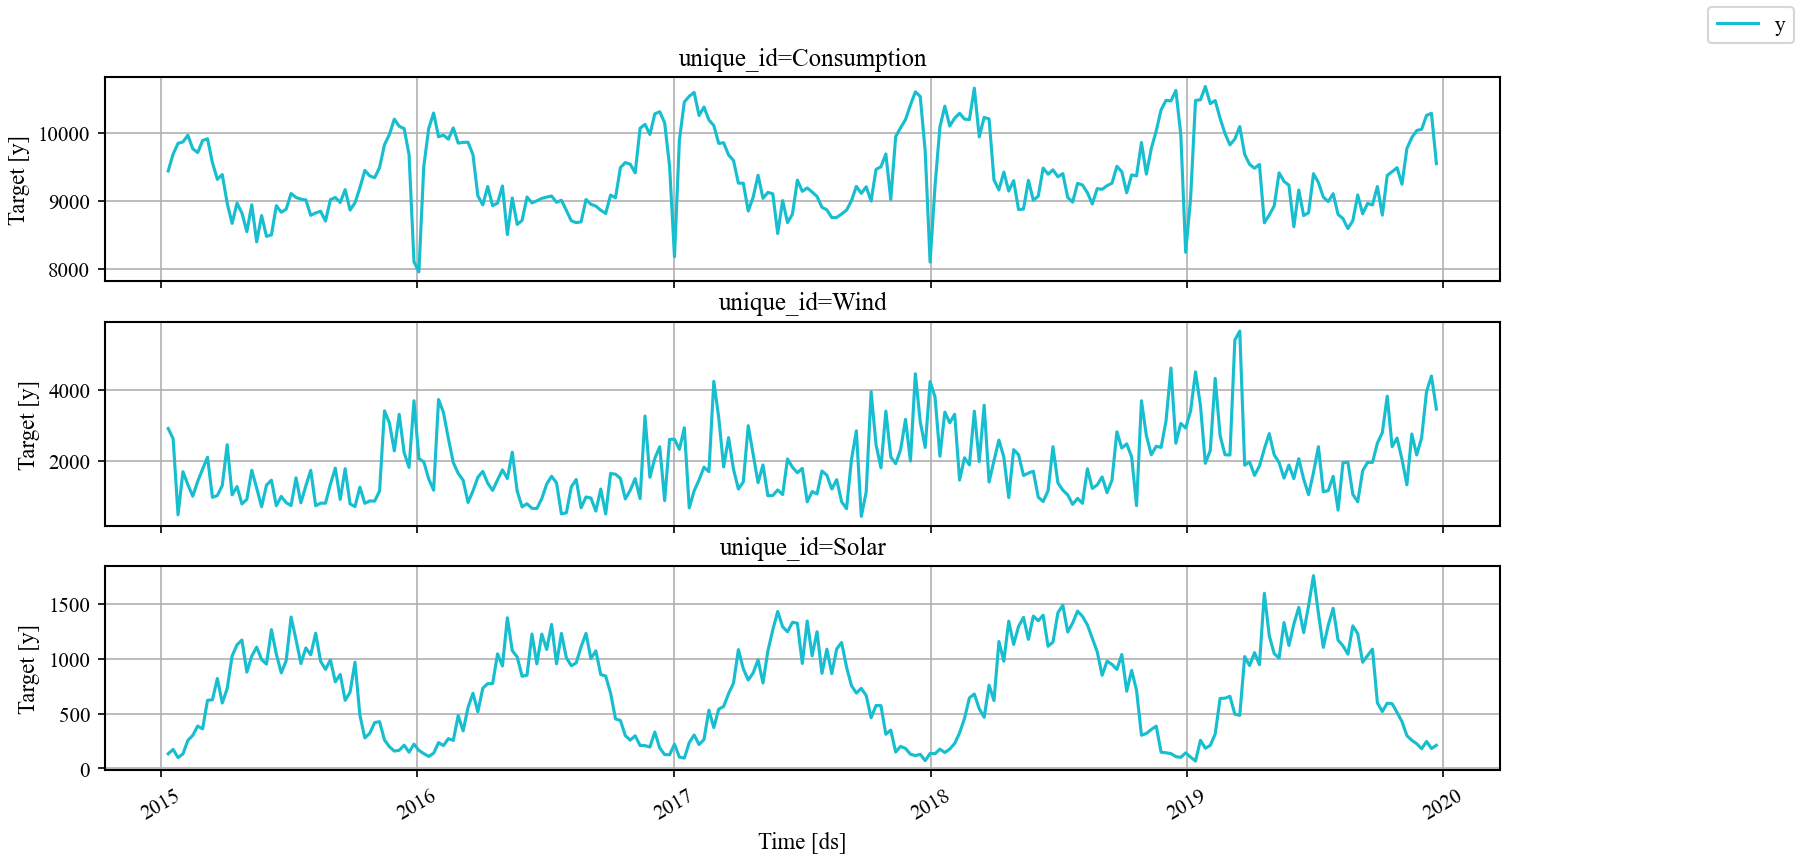

In [17]:
n_rows = len(panel_df['unique_id'].unique())
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 2*n_rows), sharex=True)
plot_series(panel_df, ax = ax)

#### Мы будем использовать иногда функцию plot_series_v2

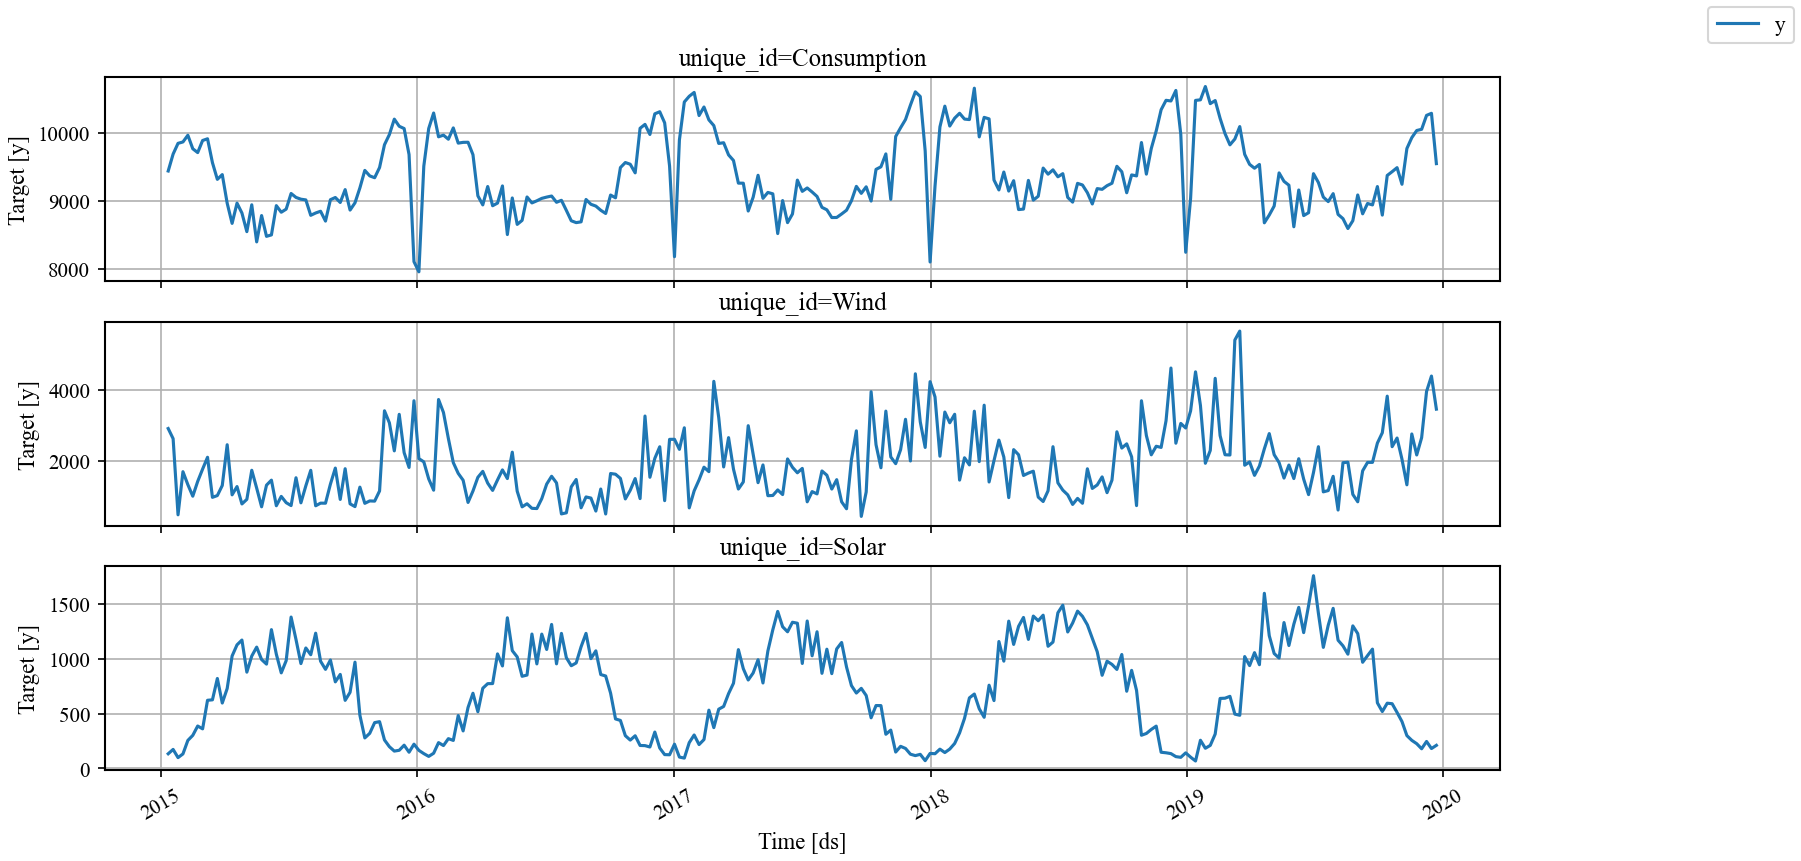

In [18]:
plot_series_v2(panel_df)

### Train Test Split

Разделим ВР на тренировочную и тестовую части. К сожалению на сегодня это возможно только в ручном режиме

In [19]:
FH = int(0.42 * y.shape[0])

In [20]:
df_test  = panel_df[base_cols].groupby("unique_id").tail(FH)
df_train = panel_df[base_cols].drop(df_test.index).reset_index(drop=True)

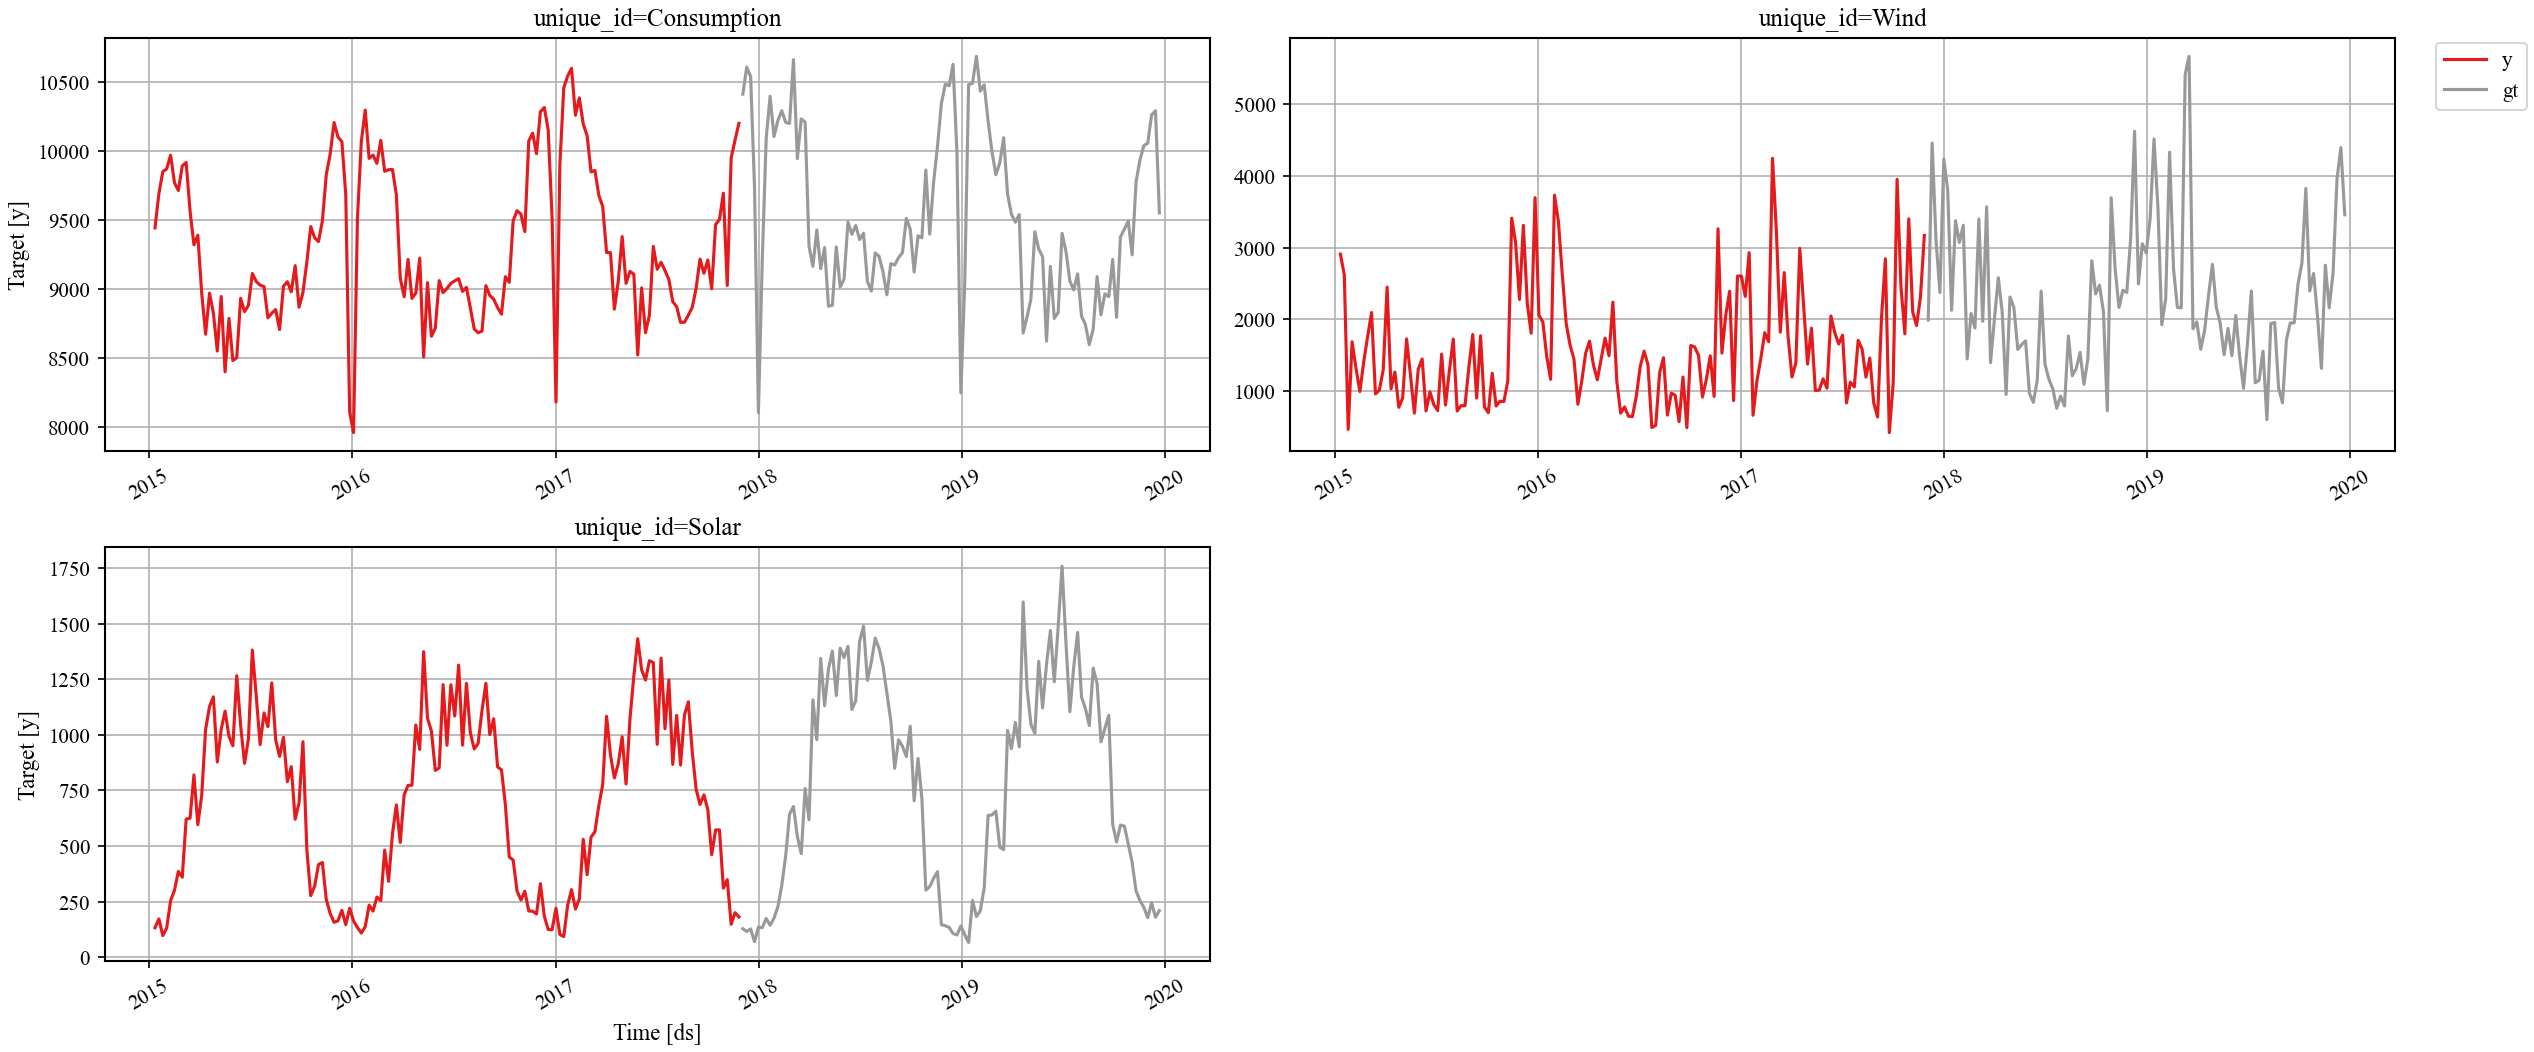

In [21]:
plot_series(df_train, df_test.rename(columns={"y": "gt"}),  palette='Set1')

## Дополнительно

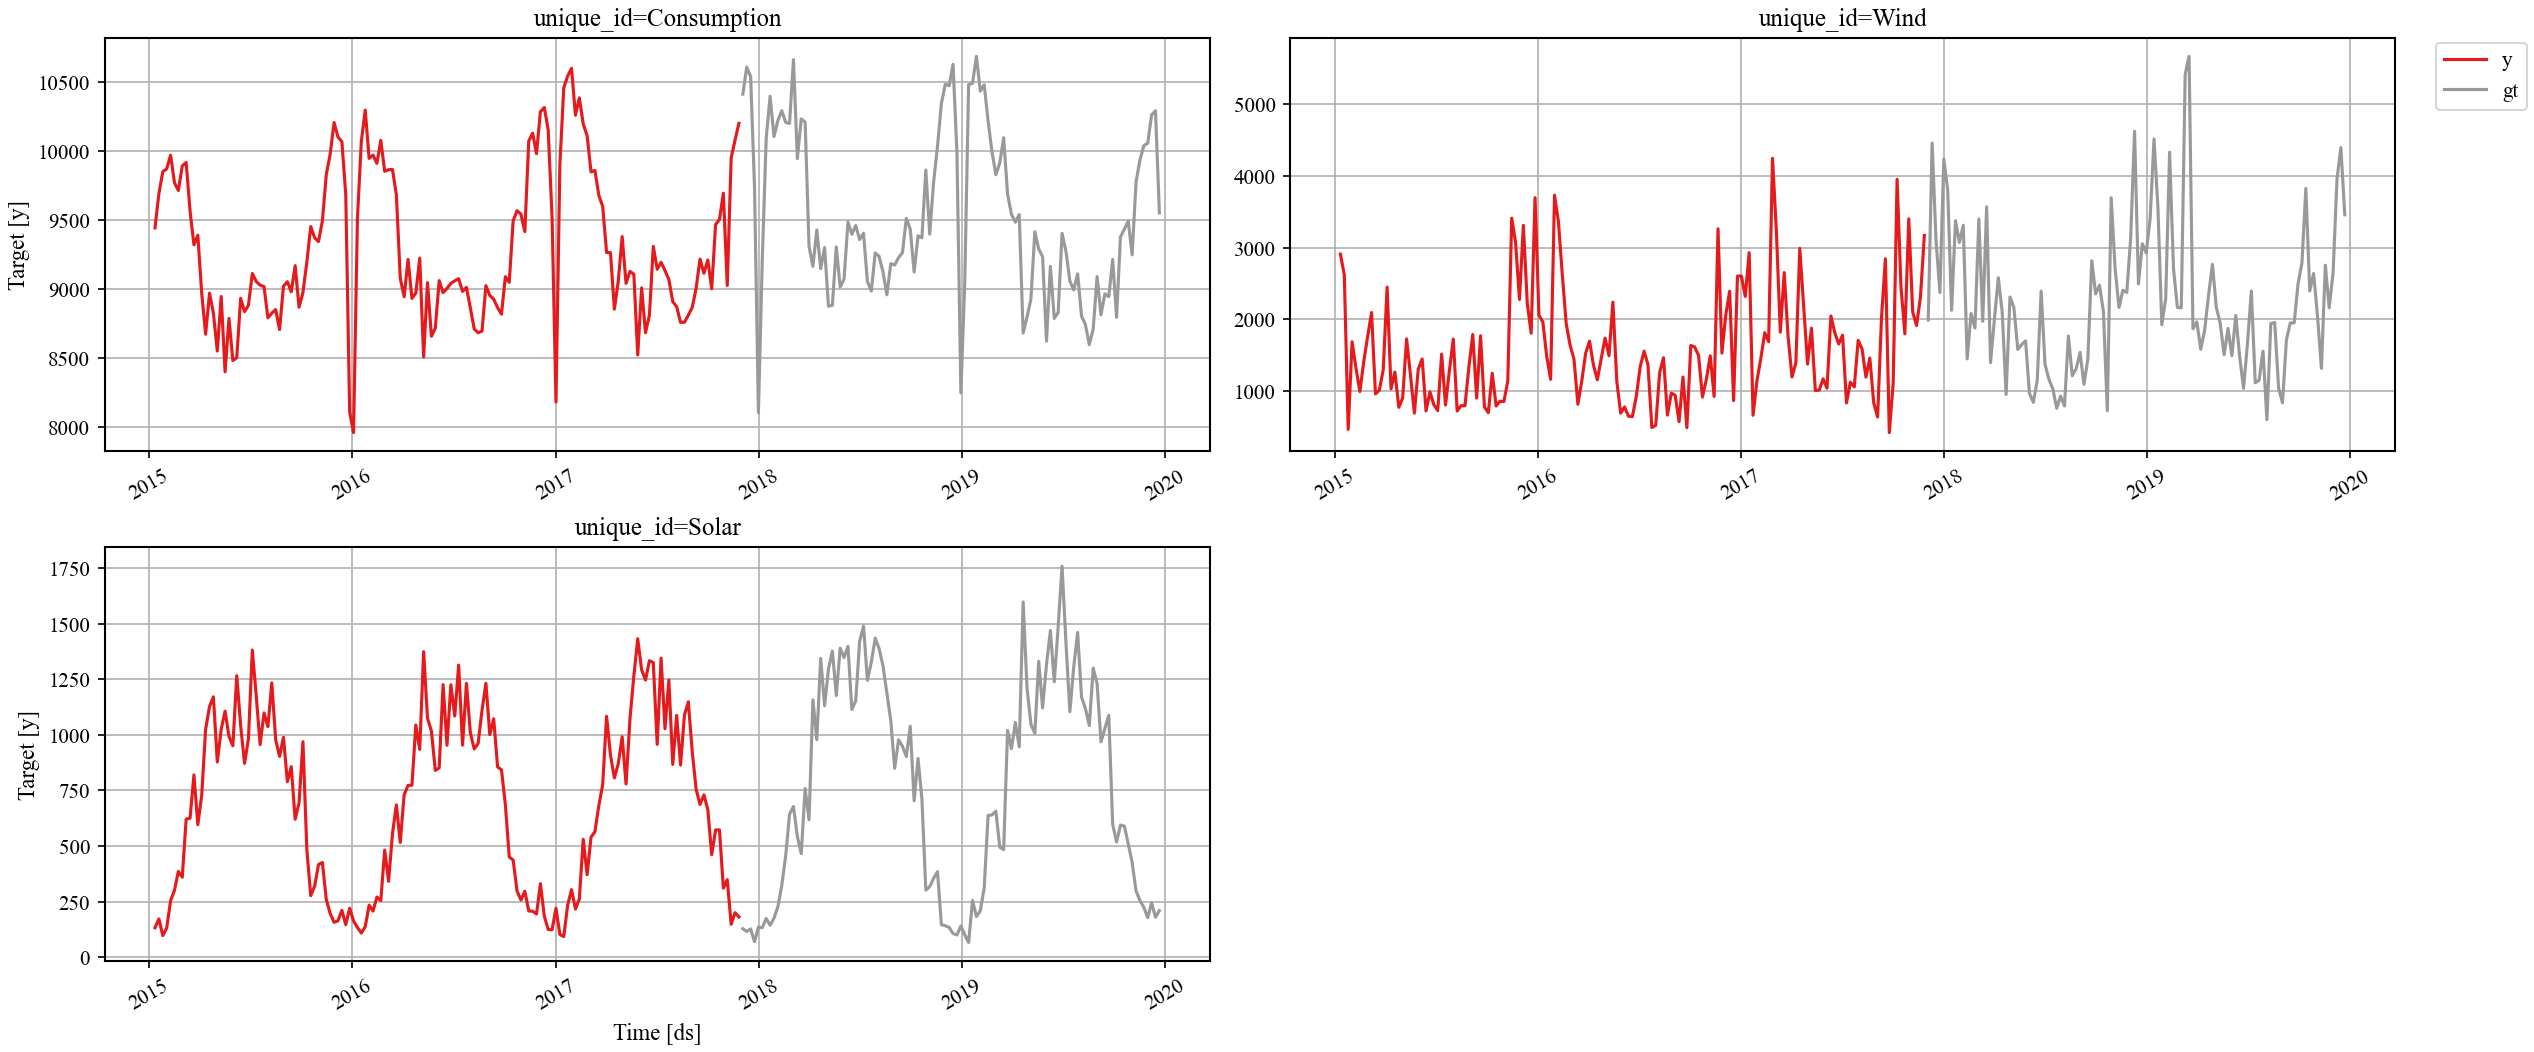

In [22]:
df= pd.read_csv(
    "OPDS_DE_EDA.csv",
    parse_dates=["time"],
    index_col="time"
)

df.head(1)
ts = ['Consumption','Wind',	'Solar']

exog_cols = ['temperature','radiation_direct_horizontal']

y = df.resample('W').agg({
    'Consumption': 'sum',
    'Wind': 'sum',
    'Solar': 'sum',
    'temperature': 'mean',
    'radiation_direct_horizontal': 'mean'
}).ffill().bfill() + 1e-8

y = y.iloc[1:-2]

ts = ['Consumption', 'Wind', 'Solar']
base_cols = ['unique_id', 'ds', 'y']

date_index = y.index
panel_list = [pd.DataFrame({'ds':date_index , 'y': y[t].values, 'unique_id': t}) for t in ts]
panel_df = pd.concat(panel_list, ignore_index=True)
panel_df = panel_df[base_cols] #порядок колонок
panel_df.sample(5)

FREQ = y.index.freq

SEASON = 52

FH = int(0.42 * y.shape[0])

df_test  = panel_df[base_cols].groupby("unique_id").tail(FH)
df_train = panel_df[base_cols].drop(df_test.index).reset_index(drop=True)

plot_series(df_train, df_test.rename(columns={"y": "gt"}),  palette='Set1')

In [28]:
import numpy as np
import pandas as pd
from typing import Optional, List, Dict
from statsforecast.models import _TS
from statsforecast.adapters.prophet import AutoARIMAProphet
from prophet.make_holidays import make_holidays_df


In [23]:
from prophet_adapter import TSProphet
from statsforecast.models import AutoARIMA

In [34]:
import numpy as np
import pandas as pd
from typing import Optional, List, Dict
from statsforecast.models import _TS
from statsforecast.adapters.prophet import AutoARIMAProphet
from prophet.make_holidays import make_holidays_df


class TSAutoARIMAProphet(_TS):
    """
    Обёртка AutoARIMAProphet для StatsForecast с:
    - freq
    - кастомными сезонностями
    - holidays
    - prediction intervals (level)
    - exogenous features (X, X_future)
    """

    _tags = {
        "python_dependencies": ["prophet", "pmdarima"],
        "capability:pred_int": True,
    }

    def __init__(
        self,
        freq: str = "H",
        yearly_seasonality="auto",
        weekly_seasonality="auto",
        daily_seasonality="auto",
        custom_seasonalities: Optional[List[Dict]] = None,
        holidays: Optional[pd.DataFrame] = None,
        country_holidays: Optional[str] = None,
        seasonality_mode: str = "additive",
        seasonality_prior_scale: float = 10.0,
        interval_width: float = 0.8,
        alias: str = "AutoARIMAProphet",
        # -------------------- ARIMA параметры --------------------
        d=None,
        D=None,
        max_p=5,
        max_q=5,
        max_P=2,
        max_Q=2,
        max_order=5,
        max_d=2,
        max_D=1,
        start_p=2,
        start_q=2,
        start_P=1,
        start_Q=1,
        stationary=False,
        seasonal=True,
        ic="aicc",
        stepwise=True,
        nmodels=94,
        trace=False,
        approximation=False,
        method=None,
        truncate=None,
        test="kpss",
        test_kwargs=None,
        seasonal_test="seas",
        seasonal_test_kwargs=None,
        allowdrift=False,
        allowmean=False,
        blambda=None,
        biasadj=False,
        period=1,
        **kwargs,
    ):
        super().__init__()
        # Prophet параметры
        self.freq = freq
        self.yearly_seasonality = yearly_seasonality
        self.weekly_seasonality = weekly_seasonality
        self.daily_seasonality = daily_seasonality
        self.custom_seasonalities = custom_seasonalities or []
        self.holidays = holidays
        self.country_holidays = country_holidays
        self.seasonality_mode = seasonality_mode
        self.seasonality_prior_scale = seasonality_prior_scale
        self.interval_width = interval_width
        self.alias = alias
        self.kwargs = kwargs

        # Сохраняем ARIMA параметры
        self.arima_kwargs = dict(
            d=d,
            D=D,
            max_p=max_p,
            max_q=max_q,
            max_P=max_P,
            max_Q=max_Q,
            max_order=max_order,
            max_d=max_d,
            max_D=max_D,
            start_p=start_p,
            start_q=start_q,
            start_P=start_P,
            start_Q=start_Q,
            stationary=stationary,
            seasonal=seasonal,
            ic=ic,
            stepwise=stepwise,
            nmodels=nmodels,
            trace=trace,
            approximation=approximation,
            method=method,
            truncate=truncate,
            test=test,
            test_kwargs=test_kwargs,
            seasonal_test=seasonal_test,
            seasonal_test_kwargs=seasonal_test_kwargs,
            allowdrift=allowdrift,
            allowmean=allowmean,
            blambda=blambda,
            biasadj=biasadj,
            period=period,
        )

    # -------------------- Внутренние функции --------------------
    def _get_ds(self, y):
        if hasattr(self, "_dates") and self._dates is not None:
            return self._dates
        return pd.date_range("1970-01-01", periods=len(y), freq=self.freq)

    def _merge_holidays(self, years):
        dfs = []
        if self.country_holidays:
            dfs.append(make_holidays_df(year_list=years, country=self.country_holidays))
        if self.holidays is not None:
            dfs.append(self.holidays.copy())
        if not dfs:
            return None
        return pd.concat(dfs, ignore_index=True)

    def _add_custom_seasonalities(self, model: AutoARIMAProphet):
        for s in self.custom_seasonalities:
            model.add_seasonality(
                name=s["name"],
                period=s["period"],
                fourier_order=s.get("fourier_order", 5),
            )

    # -------------------- _create_model --------------------
    def _create_model(self, interval_width: float, years=None):
        holidays_df = self._merge_holidays(years)
        model = AutoARIMAProphet(
            yearly_seasonality=self.yearly_seasonality,
            weekly_seasonality=self.weekly_seasonality,
            daily_seasonality=self.daily_seasonality,
            holidays=holidays_df,
            seasonality_mode=self.seasonality_mode,
            seasonality_prior_scale=self.seasonality_prior_scale,
            interval_width=interval_width,
            **self.arima_kwargs,
            **self.kwargs,
        )
        self._add_custom_seasonalities(model)
        return model

    # -------------------- API SF --------------------
    def fit(self, y: np.ndarray, X: Optional[np.ndarray] = None, level=None):
        ds = self._get_ds(y)
        df = pd.DataFrame({"ds": ds, "y": y})
        self.history = df.copy()
        years = sorted(set(pd.to_datetime(ds).year))
        self.model_ = self._create_model(interval_width=self.interval_width, years=years)
        self.model_.fit(df)
        self.xreg_cols = None
        if X is not None:
            self.xreg_cols = [f"x{i}" for i in range(X.shape[1])]
        return self

    def predict_in_sample(self, level: Optional[List[int]] = None):
        if not hasattr(self, "model_"):
            raise RuntimeError("Model is not fitted")
        df = self.history
        fcst = self.model_.predict(df)
        values = [fcst["yhat"].to_numpy()]
        cols = ["fitted"]
        if level:
            for lv in level:
                values.extend([fcst["yhat_lower"].to_numpy(), fcst["yhat_upper"].to_numpy()])
                cols.extend([f"lo-{lv}", f"hi-{lv}"])
        values = np.column_stack(values)
        return {"values": values, "cols": cols}

    def forecast(
        self,
        y: np.ndarray,
        h: int,
        X: Optional[np.ndarray] = None,
        X_future: Optional[np.ndarray] = None,
        level: Optional[List[int]] = None,
        fitted: bool = False,
    ):
        self.fit(y=y, X=X, level=level)
        start_date = self.history["ds"].iloc[-1]
        future = pd.DataFrame({
            "ds": pd.date_range(start=start_date + pd.Timedelta(1, unit=self.freq[0]), periods=h, freq=self.freq)
        })
        fcst = self.model_.predict(future)
        res = {"mean": fcst["yhat"].to_numpy()}
        if level:
            for lv in level:
                res[f"lo-{lv}"] = fcst["yhat_lower"].to_numpy()
                res[f"hi-{lv}"] = fcst["yhat_upper"].to_numpy()
        if fitted:
            ins = self.model_.predict(self.history)
            res["fitted"] = ins["yhat"].to_numpy()
            if level:
                for lv in level:
                    res[f"fitted-lo-{lv}"] = ins["yhat_lower"].to_numpy()
                    res[f"fitted-hi-{lv}"] = ins["yhat_upper"].to_numpy()
        return res

    def forward(
        self,
        y: np.ndarray,
        h: int,
        X: Optional[np.ndarray] = None,
        X_future: Optional[np.ndarray] = None,
        level: Optional[List[int]] = None,
        fitted: bool = False,
    ):
        return self.forecast(y=y, h=h, X=X, X_future=X_future, level=level, fitted=fitted)


In [39]:
import pandas as pd
import numpy as np
from typing import Optional, List, Dict
from statsforecast.models import _TS
from statsforecast.adapters.prophet import AutoARIMAProphet
from prophet.make_holidays import make_holidays_df

class TSAutoARIMAProphet(_TS):
    _tags = {"python_dependencies": ["prophet"], "capability:pred_int": True}

    def __init__(
        self,
        yearly_seasonality="auto",
        weekly_seasonality="auto",
        daily_seasonality="auto",
        custom_seasonalities: Optional[List[Dict]] = None,
        holidays: Optional[pd.DataFrame] = None,
        country_holidays: Optional[str] = None,
        seasonality_mode="additive",
        seasonality_prior_scale=10.0,
        interval_width=0.8,
        alias="AutoARIMAProphet",
        # --- ARIMA params ---
        d=None,
        D=None,
        max_p=5,
        max_q=5,
        max_P=2,
        max_Q=2,
        max_order=5,
        max_d=2,
        max_D=1,
        start_p=2,
        start_q=2,
        start_P=1,
        start_Q=1,
        stationary=False,
        seasonal=True,
        ic="aicc",
        stepwise=True,
        nmodels=94,
        trace=False,
        approximation=False,
        method=None,
        truncate=None,
        test="kpss",
        test_kwargs=None,
        seasonal_test="seas",
        seasonal_test_kwargs=None,
        allowdrift=False,
        allowmean=False,
        blambda=None,
        biasadj=False,
        period=1,
        **kwargs,
    ):
        super().__init__()

        self.yearly_seasonality = yearly_seasonality
        self.weekly_seasonality = weekly_seasonality
        self.daily_seasonality = daily_seasonality
        self.custom_seasonalities = custom_seasonalities or []
        self.holidays = holidays
        self.country_holidays = country_holidays
        self.seasonality_mode = seasonality_mode
        self.seasonality_prior_scale = seasonality_prior_scale
        self.interval_width = interval_width
        self.alias = alias
        self.kwargs = kwargs

        # сохраняем ARIMA параметры
        self.arima_kwargs = dict(
            d=d, D=D,
            max_p=max_p, max_q=max_q,
            max_P=max_P, max_Q=max_Q,
            max_order=max_order,
            max_d=max_d, max_D=max_D,
            start_p=start_p, start_q=start_q,
            start_P=start_P, start_Q=start_Q,
            stationary=stationary,
            seasonal=seasonal,
            ic=ic,
            stepwise=stepwise,
            nmodels=nmodels,
            trace=trace,
            approximation=approximation,
            method=method,
            truncate=truncate,
            test=test,
            test_kwargs=test_kwargs,
            seasonal_test=seasonal_test,
            seasonal_test_kwargs=seasonal_test_kwargs,
            allowdrift=allowdrift,
            allowmean=allowmean,
            blambda=blambda,
            biasadj=biasadj,
            period=period,
        )

    # -------------------------------
    def _merge_holidays(self, years):
        dfs = []
        if self.country_holidays:
            dfs.append(make_holidays_df(year_list=years, country=self.country_holidays))
        if self.holidays is not None:
            dfs.append(self.holidays.copy())
        if not dfs:
            return None
        return pd.concat(dfs, ignore_index=True)

    def _add_custom_seasonalities(self, model: AutoARIMAProphet):
        for s in self.custom_seasonalities:
            model.add_seasonality(
                name=s["name"],
                period=s["period"],
                fourier_order=s.get("fourier_order", 5),
            )

    def _create_model(self, years=None):
        holidays_df = self._merge_holidays(years)
        model = AutoARIMAProphet(
            yearly_seasonality=self.yearly_seasonality,
            weekly_seasonality=self.weekly_seasonality,
            daily_seasonality=self.daily_seasonality,
            holidays=holidays_df,
            seasonality_mode=self.seasonality_mode,
            seasonality_prior_scale=self.seasonality_prior_scale,
            interval_width=self.interval_width,
            **self.arima_kwargs,
            **self.kwargs,
        )
        self._add_custom_seasonalities(model)
        return model

    # -------------------------------
    def fit(self, df: pd.DataFrame, X=None):
        ds = pd.to_datetime(df["ds"])
        years = sorted(set(ds.dt.year))
        self.model_ = self._create_model(years)
        self.model_.fit(df)
        self.history = df.copy()
        self.X_cols = X.columns if X is not None else None
        self.X = X
        return self

    def predict(self, h=None, X_future=None):
        if self.model_ is None:
            raise RuntimeError("Model is not fitted.")
        if X_future is not None:
            fcst = self.model_.predict(X_future)
        else:
            fcst = self.model_.predict()
        return fcst

    def predict_in_sample(self, level: Optional[List[int]] = None):
        if self.model_ is None:
            raise RuntimeError("Model is not fitted.")
        ins = self.model_.predict(self.history)
        if level:
            # интервалы
            ins["yhat_lower"] = ins["yhat_lower"]
            ins["yhat_upper"] = ins["yhat_upper"]
        return ins

    def forecast(self, h, X_future=None, level: Optional[List[int]] = None):
        return self.predict(h=h, X_future=X_future)

    def forward(self, h, X_future=None, level: Optional[List[int]] = None):
        return self.predict(h=h, X_future=X_future)


In [46]:
import numpy as np
import pandas as pd
from typing import Optional, List, Dict, Any
from statsforecast.models import _TS, AutoARIMA
from prophet import Prophet

class TSAutoARIMAProphet(_TS):
    """
    Нативная реализация AutoARIMAProphet для StatsForecast.
    Использует Prophet для генерации экзогенных признаков (сезонность, праздники)
    и AutoARIMA в качестве финального оценщика.
    """
    
    _tags = {
        "python_dependencies": ["prophet"],
        "capability:pred_int": True,
        "capability:exogenous": True,
    }

    def __init__(
        self,
        freq: str = 'D',
        # Параметры Prophet
        growth="linear",
        yearly_seasonality="auto",
        weekly_seasonality="auto",
        daily_seasonality="auto",
        holidays=None,
        seasonality_mode="additive",
        # Параметры AutoARIMA
        d=None, D=None, max_p=5, max_q=5, max_P=2, max_Q=2,
        max_order=5, max_d=2, max_D=1, start_p=2, start_q=2,
        start_P=1, start_Q=1, stationary=False, seasonal=True,
        ic="aicc", stepwise=True, period=1,
        alias: str = "AutoARIMAProphet",
        **kwargs
    ):
        super().__init__()
        self.freq = freq
        self.alias = alias
        
        # Сохраняем настройки для инициализации Prophet
        self.prophet_config = {
            'growth': growth,
            'yearly_seasonality': yearly_seasonality,
            'weekly_seasonality': weekly_seasonality,
            'daily_seasonality': daily_seasonality,
            'holidays': holidays,
            'seasonality_mode': seasonality_mode,
            **kwargs
        }
        
        # Инициализируем движок ARIMA
        self.arima_engine = AutoARIMA(
            d=d, D=D, max_p=max_p, max_q=max_q, max_P=max_P, max_Q=max_Q,
            max_order=max_order, max_d=max_d, max_D=max_D, start_p=start_p,
            start_q=start_q, start_P=start_P, start_Q=start_Q,
            stationary=stationary, seasonal=seasonal, ic=ic,
            stepwise=stepwise, 
            season_length=period # <--- Исправлено здесь
        )

    def _make_prophet_features(self, y: np.ndarray, X: Optional[np.ndarray] = None, h: int = 0):
        """Внутренняя магия генерации признаков из пайплайна Prophet"""
        if hasattr(self, "_dates") and self._dates is not None:
            ds = self._dates
        else:
            ds = pd.date_range(end=pd.Timestamp.now(), periods=len(y), freq=self.freq)
            
        df = pd.DataFrame({'ds': ds, 'y': y})
        
        # Создаем временный объект Prophet для экстракции признаков
        m = Prophet(**self.prophet_config)
        m.fit(df)
        
        if h > 0:
            future = m.make_future_dataframe(periods=h, freq=self.freq, include_history=False)
            full_df = future
        else:
            full_df = df
            
        # Извлекаем компоненты (сезонности + праздники)
        seasonal_features = m.make_all_seasonality_features(full_df)[0]
        
        # Удаляем лишние колонки, оставляем только те, что сгенерировал Prophet
        # (обычно это Фурье-компоненты и бинарные флаги праздников)
        X_prophet = seasonal_features.values
        return X_prophet, seasonal_features.columns

    def fit(self, y: np.ndarray, X: Optional[np.ndarray] = None):
        # 1. Генерируем признаки из Prophet
        X_prophet, self.xreg_cols = self._make_prophet_features(y, X)
        
        # 2. Если были внешние X, объединяем их с признаками Prophet
        X_final = np.hstack([X, X_prophet]) if X is not None else X_prophet
        
        # 3. Учим ARIMA на всем этом добре
        self.arima_engine.fit(y=y, X=X_final)
        return self

    def predict(self, h: int, X: Optional[np.ndarray] = None, level: Optional[List[int]] = None):
        # Генерируем признаки Prophet на будущее
        # Мы берем dummy-y, но Prophet важны даты. 
        # Он сгенерирует фичи на основе freq и последнего состояния.
        y_dummy = np.zeros(h) 
        X_prophet_future, _ = self._make_prophet_features(y_dummy, h=h)
        
        # Если есть внешние X (от пользователя), клеим их в начало, как при fit
        if X is not None:
            X_final = np.hstack([X, X_prophet_future])
        else:
            X_final = X_prophet_future
        
        return self.arima_engine.predict(h=h, X=X_final, level=level)

    def forecast(self, y, h, X=None, X_future=None, level=None, fitted=False):
        self.fit(y, X)
        out = self.predict(h, X_future, level)
        if fitted:
            # StatsForecast ожидает 'fitted' в словаре
            in_sample = self.arima_engine.predict_in_sample(level=level)
            out = {**out, **in_sample}
        return out

    def forward(self, y, h, X=None, X_future=None, level=None, fitted=False):
        return self.forecast(y, h, X, X_future, level, fitted)
    def predict_in_sample(self, level: Optional[List[int]] = None):
        """
        Возвращает подогнанные значения (fitted values) для обучающей выборки.
        """
        if not hasattr(self.arima_engine, 'model_'):
            raise Exception("Модель еще не обучена. Сначала вызовите fit().")

        # AutoARIMA в StatsForecast возвращает словарь с 'fitted' и интервалами
        # Мы просто транслируем это наверх
        return self.arima_engine.predict_in_sample(level=level)

In [47]:
from statsforecast import StatsForecast
LEVELS = [70,90]

models = [TSAutoARIMAProphet(yearly_seasonality=True, alias='test_1' ),
          # TSAutoARIMAProphet(freq=FREQ, 
          #          seasonality_mode='additive',
          #                n_changepoints=int(len(df_train) / 4),
          #                add_country_holidays="RU",
          #                yearly_seasonality=True)
         ]

sf = StatsForecast(models=models, freq=FREQ, n_jobs=1)

fcst_sf = sf.forecast(df=df_train, h=FH, level = LEVELS, fitted=True)

in_sample = sf.forecast_fitted_values()

eval_sf = df_test.merge(fcst_sf, on=['unique_id', 'ds'])

22:49:28 - cmdstanpy - INFO - Chain [1] start processing
22:49:28 - cmdstanpy - INFO - Chain [1] done processing
22:49:29 - cmdstanpy - INFO - Chain [1] start processing
22:49:29 - cmdstanpy - INFO - Chain [1] done processing
22:49:30 - cmdstanpy - INFO - Chain [1] start processing
22:49:30 - cmdstanpy - INFO - Chain [1] done processing


In [48]:
in_sample

,unique_id,ds,y,test_1,test_1-lo-90,test_1-lo-70,test_1-hi-70,test_1-hi-90
0,Consumption,2015-01-11,9440.105,9507.221477,8964.611948,9165.319545,9849.123409,10049.831006
1,Consumption,2015-01-18,9689.010,9583.474644,9040.865115,9241.572712,9925.376576,10126.084173
2,Consumption,2015-01-25,9847.035,9778.809670,9236.200142,9436.907738,10120.711602,10321.419199
3,Consumption,2015-02-01,9867.317,9918.139609,9375.530080,9576.237677,10260.041541,10460.749138
4,Consumption,2015-02-08,9966.415,9947.470382,9404.860853,9605.568450,10289.372314,10490.079910
...,...,...,...,...,...,...,...,...
448,Wind,2017-10-29,3400.181,3007.427792,2066.398819,2414.479075,3600.376510,3948.456766
449,Wind,2017-11-05,2105.870,2424.720288,1483.691314,1831.771570,3017.669005,3365.749261
450,Wind,2017-11-12,1914.513,2067.944504,1126.915530,1474.995786,2660.893221,3008.973477
451,Wind,2017-11-19,2309.436,2027.147021,1086.118048,1434.198304,2620.095739,2968.175995


In [49]:
fcst_sf

,unique_id,ds,test_1,test_1-lo-90,test_1-lo-70,test_1-hi-70,test_1-hi-90
0,Consumption,2017-12-03,1.110401e+04,1.056140e+04,1.076210e+04,1.144591e+04,1.164662e+04
1,Consumption,2017-12-10,1.267950e+04,1.207414e+04,1.229806e+04,1.306094e+04,1.328485e+04
2,Consumption,2017-12-17,1.553273e+04,1.492738e+04,1.515129e+04,1.591417e+04,1.613809e+04
3,Consumption,2017-12-24,2.030250e+04,1.969715e+04,1.992106e+04,2.068394e+04,2.090786e+04
4,Consumption,2017-12-31,2.809746e+04,2.749211e+04,2.771602e+04,2.847890e+04,2.870282e+04
...,...,...,...,...,...,...,...
319,Wind,2019-11-24,1.887754e+11,1.887754e+11,1.887754e+11,1.887754e+11,1.887754e+11
320,Wind,2019-12-01,1.889171e+11,1.889171e+11,1.889171e+11,1.889171e+11,1.889171e+11
321,Wind,2019-12-08,1.887073e+11,1.887073e+11,1.887073e+11,1.887073e+11,1.887073e+11
322,Wind,2019-12-15,1.881473e+11,1.881473e+11,1.881473e+11,1.881473e+11,1.881473e+11


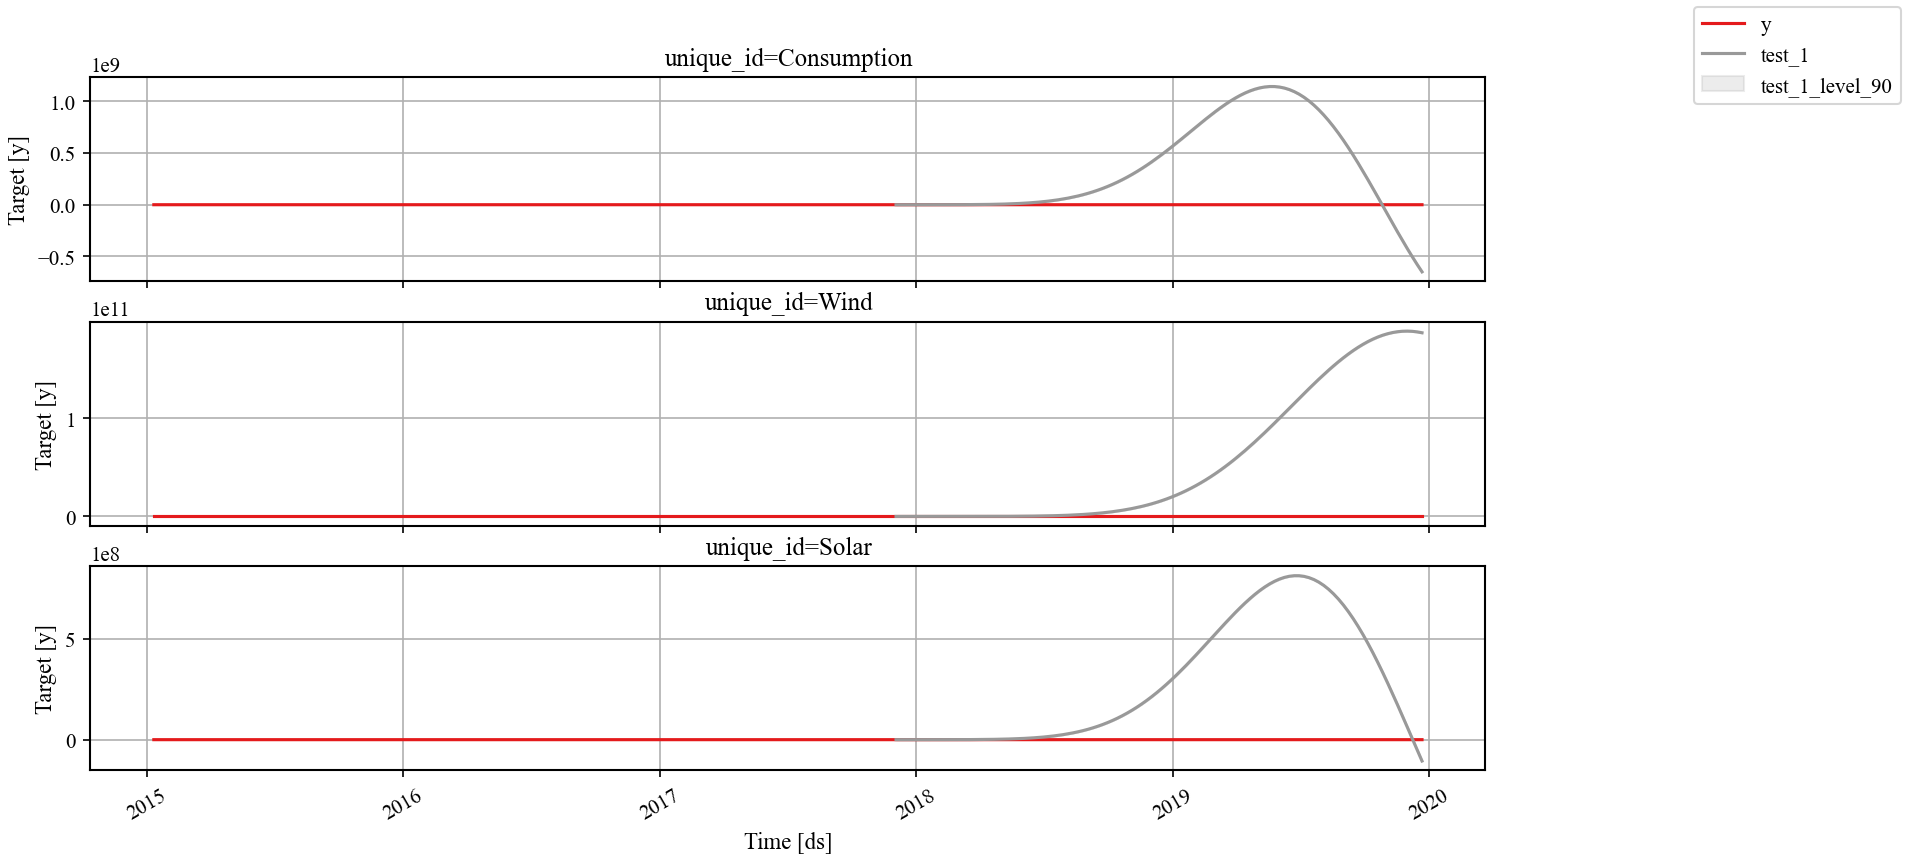

In [50]:

evaluate_and_plot(df_train, df_test, eval_sf, metrics = [mae, rmse, ], levels=LEVELS[1:])

In [102]:
cv_df = sf.cross_validation(
    df=panel_df,
    h=FH//2,
    n_windows=4,
    step_size=FH//2, 
    # refit=True,
)
cv_df.head()

21:58:50 - cmdstanpy - INFO - Chain [1] start processing
21:58:50 - cmdstanpy - INFO - Chain [1] done processing
21:58:50 - cmdstanpy - INFO - Chain [1] start processing
21:58:51 - cmdstanpy - INFO - Chain [1] done processing
21:58:51 - cmdstanpy - INFO - Chain [1] start processing
21:58:51 - cmdstanpy - INFO - Chain [1] done processing
21:58:51 - cmdstanpy - INFO - Chain [1] start processing
21:58:52 - cmdstanpy - INFO - Chain [1] done processing
21:58:52 - cmdstanpy - INFO - Chain [1] start processing
21:58:52 - cmdstanpy - INFO - Chain [1] done processing
21:58:52 - cmdstanpy - INFO - Chain [1] start processing
21:58:52 - cmdstanpy - INFO - Chain [1] done processing
21:58:52 - cmdstanpy - INFO - Chain [1] start processing
21:58:52 - cmdstanpy - INFO - Chain [1] done processing
21:58:52 - cmdstanpy - INFO - Chain [1] start processing
21:58:52 - cmdstanpy - INFO - Chain [1] done processing
21:58:52 - cmdstanpy - INFO - Chain [1] start processing
21:58:53 - cmdstanpy - INFO - Chain [1]

,unique_id,ds,cutoff,y,test_1,Prophet
0,Consumption,2015-11-08,2015-11-01,9491.391,9944.701083,9944.923535
1,Consumption,2015-11-15,2015-11-01,9826.524,12341.762436,12342.311465
2,Consumption,2015-11-22,2015-11-01,9976.205,17179.874405,17180.886312
3,Consumption,2015-11-29,2015-11-01,10203.088,24010.325684,24011.763932
4,Consumption,2015-12-06,2015-11-01,10097.922,31310.819069,31312.447556


In [103]:
from statsforecast.utils import ConformalIntervals

# Безопасный горизонт для конформной калибровки
h = min(FH, df_train.groupby('unique_id').size().min() // 3)

# Конформная калибровка (n_windows=2 обязательно)
pi = ConformalIntervals(h=h, n_windows=2)

forecasts = sf.forecast(
    df=df_train,
    h=h,
    level=LEVELS,           # уровень PI
    prediction_intervals=pi
)

21:59:51 - cmdstanpy - INFO - Chain [1] start processing
21:59:51 - cmdstanpy - INFO - Chain [1] done processing
21:59:51 - cmdstanpy - INFO - Chain [1] start processing
21:59:51 - cmdstanpy - INFO - Chain [1] done processing
21:59:51 - cmdstanpy - INFO - Chain [1] start processing
21:59:51 - cmdstanpy - INFO - Chain [1] done processing
21:59:51 - cmdstanpy - INFO - Chain [1] start processing
21:59:51 - cmdstanpy - INFO - Chain [1] done processing
21:59:51 - cmdstanpy - INFO - Chain [1] start processing
21:59:51 - cmdstanpy - INFO - Chain [1] done processing
21:59:51 - cmdstanpy - INFO - Chain [1] start processing
21:59:51 - cmdstanpy - INFO - Chain [1] done processing


In [104]:
forecasts

,unique_id,ds,test_1,test_1-lo-70,test_1-hi-70,test_1-lo-90,test_1-hi-90,Prophet,Prophet-lo-70,Prophet-hi-70,Prophet-lo-90,Prophet-hi-90
0,Consumption,2017-12-03,10492.007309,10150.438452,10828.197231,10150.438452,10828.197231,10490.751009,10151.928652,10856.736988,10151.928652,10856.736988
1,Consumption,2017-12-10,10292.650702,9926.954331,10660.188289,9926.954331,10660.188289,10291.110062,9933.638536,10649.238715,9933.638536,10649.238715
2,Consumption,2017-12-17,9679.310599,9292.279465,10018.491534,9292.279465,10018.491534,9677.361776,9308.960257,10022.506824,9308.960257,10022.506824
3,Consumption,2017-12-24,9024.742835,8675.483852,9371.304319,8675.483852,9371.304319,9022.829199,8652.330528,9380.182304,8652.330528,9380.182304
4,Consumption,2017-12-31,8796.851975,8462.162646,9137.134190,8462.162646,9137.134190,8795.813768,8449.573722,9143.539656,8449.573722,9143.539656
...,...,...,...,...,...,...,...,...,...,...,...,...
145,Wind,2018-10-14,2178.283991,1101.202365,3271.067503,1101.202365,3271.067503,2175.645368,1138.835592,3160.370416,1138.835592,3160.370416
146,Wind,2018-10-21,2067.807445,973.823232,3179.910359,973.823232,3179.910359,2067.492634,1031.429398,3120.975600,1031.429398,3120.975600
147,Wind,2018-10-28,1850.804228,805.412570,2968.099893,805.412570,2968.099893,1853.042889,826.422871,2921.554366,826.422871,2921.554366
148,Wind,2018-11-04,1896.198400,759.705923,3019.188465,759.705923,3019.188465,1895.428338,820.941767,2929.659580,820.941767,2929.659580


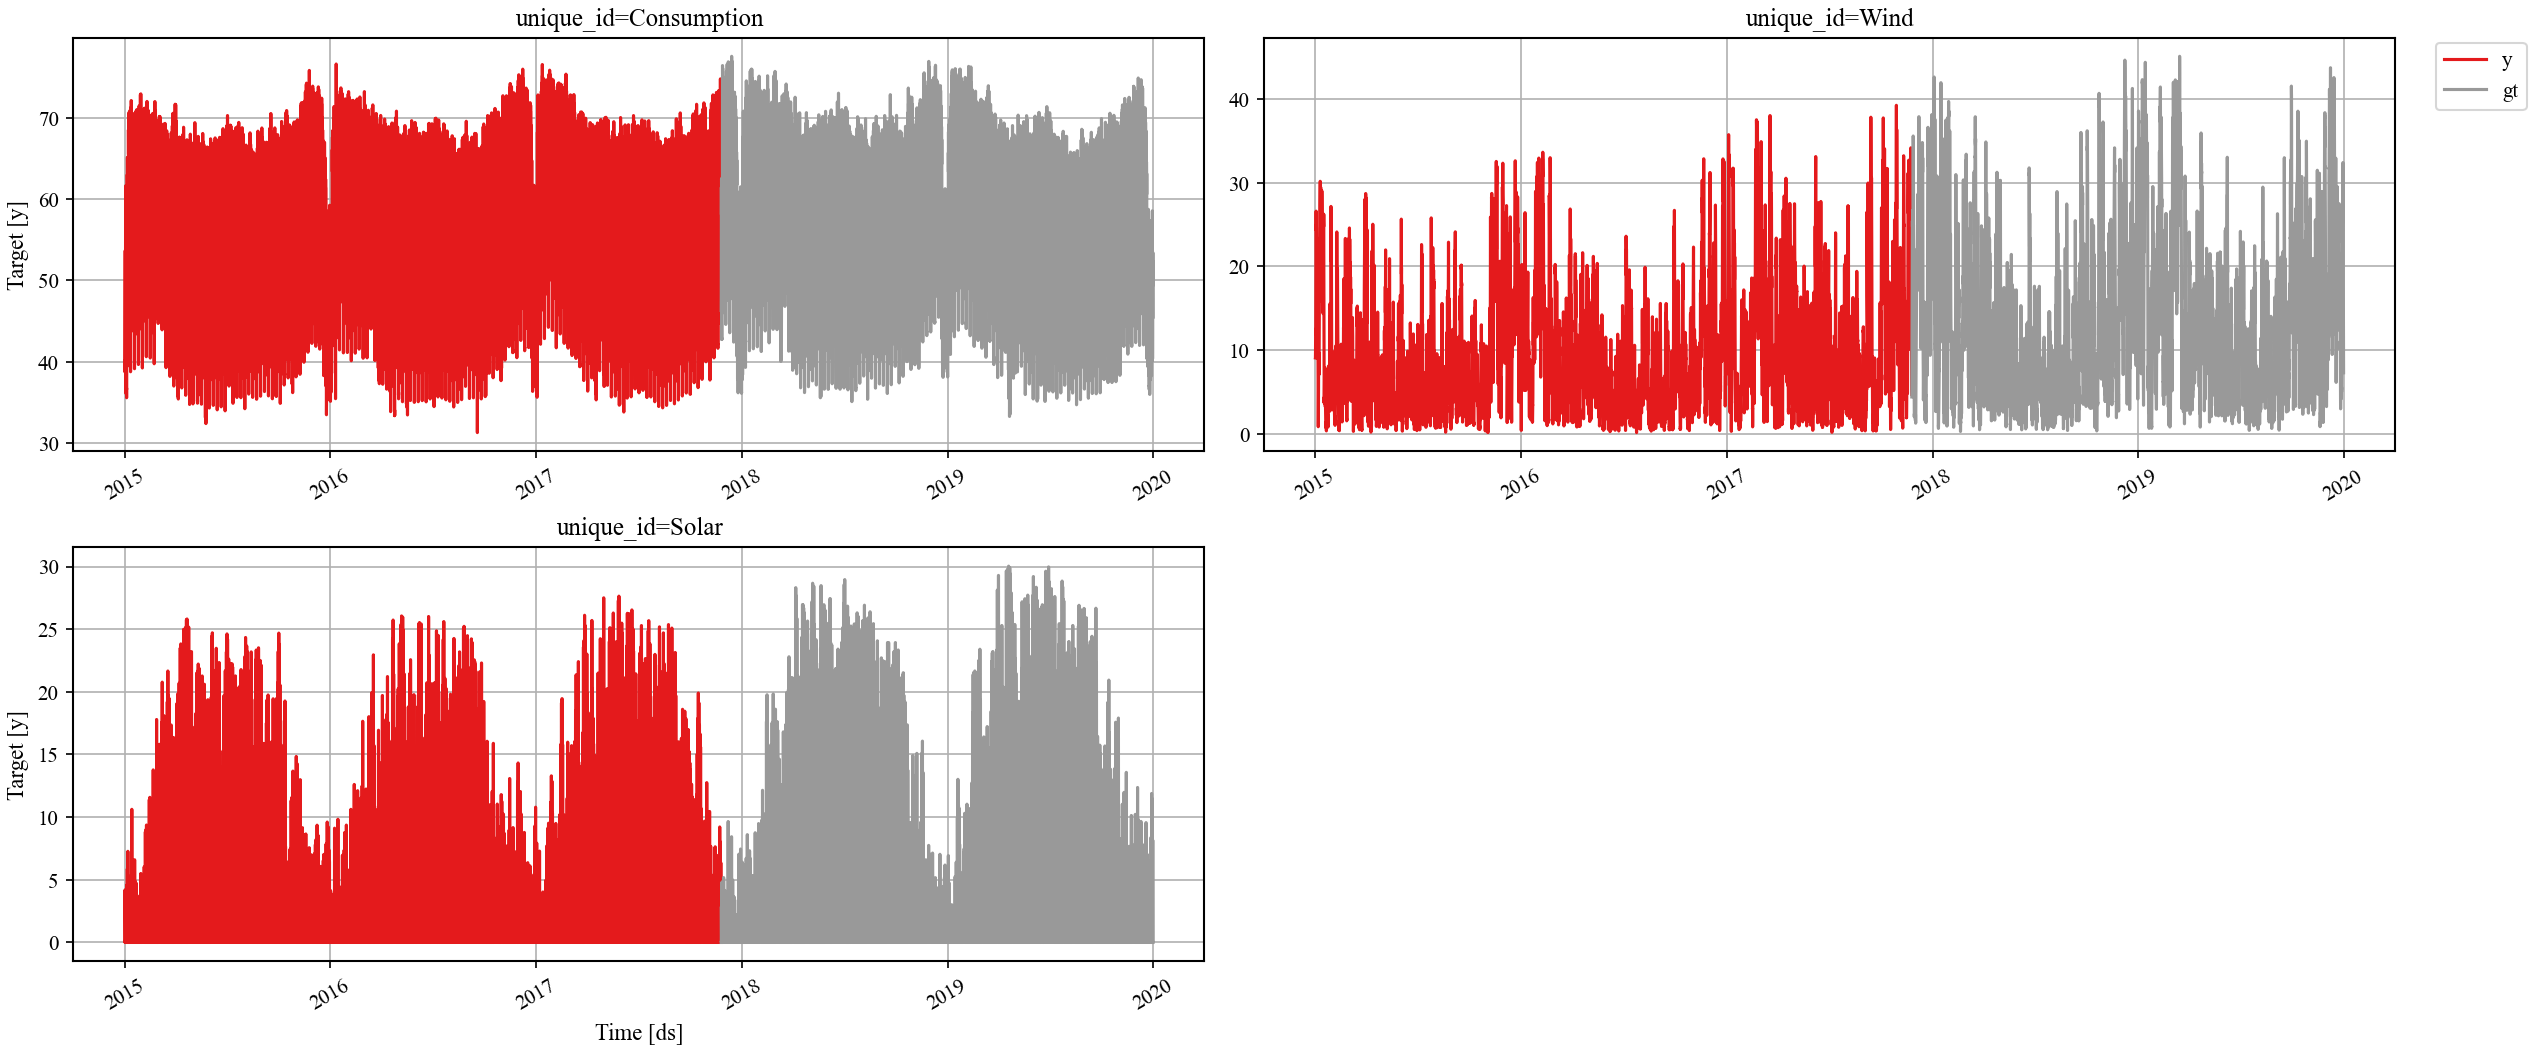

In [72]:
y = df_.resample('h').agg({
    'Consumption': 'sum',
    'Wind': 'sum',
    'Solar': 'sum',
    'temperature': 'mean',
    'radiation_direct_horizontal': 'mean'
}).ffill().bfill() + 1e-8

y = y.iloc[1:-2]



ts = ['Consumption', 'Wind', 'Solar']
base_cols = ['unique_id', 'ds', 'y']

date_index = y.index
panel_list = [pd.DataFrame({'ds':date_index , 'y': y[t].values, 'unique_id': t}) for t in ts]
panel_df = pd.concat(panel_list, ignore_index=True)
panel_df = panel_df[base_cols] #порядок колонок
panel_df.sample(5)

FREQ = y.index.freq


SEASON = [24,24*7,int(24*365.25)] 

FH = int(0.42 * y.shape[0])

df_test  = panel_df[base_cols].groupby("unique_id").tail(FH)
df_train = panel_df[base_cols].drop(df_test.index).reset_index(drop=True)

plot_series(df_train, df_test.rename(columns={"y": "gt"}),  palette='Set1')

In [74]:
custom_seasonalities = [
    {"name": "hourly", "period": 24, "fourier_order": 8},
    {"name": "half_day", "period": 12, "fourier_order": 5},
]

models = [TSProphet(freq=FREQ,     
                    weekly_seasonality=True,
                    yearly_seasonality=True,
                    daily_seasonality=True, alias='test_1' ),
          TSProphet(freq=FREQ, 
                       seasonality_mode='additive',
                        seasonality_prior_scale=0.9,  # уменьшили — сезонность будет мягче
                        changepoint_prior_scale=0.01,  # уменьшили — тренд будет мягче
                        add_country_holidays='GE',
                        weekly_seasonality=True,
                        yearly_seasonality=True,
                        daily_seasonality=True,),
        TSProphet(freq=FREQ, 
                       seasonality_mode='additive',
                        seasonality_prior_scale=0.9,  # уменьшили — сезонность будет мягче
                        changepoint_prior_scale=0.01,  # уменьшили — тренд будет мягче
                        add_country_holidays='GE',
                        weekly_seasonality=True,
                        yearly_seasonality=True,
                        daily_seasonality=False,
                        custom_seasonalities=custom_seasonalities, 
                        alias='test_custom'),
         ]




sf = StatsForecast(models=models, freq=FREQ, n_jobs=1)

fcst_sf = sf.forecast(df=df_train, h=FH, level = LEVELS, fitted=True)

in_sample = sf.forecast_fitted_values()

eval_sf = df_test.merge(fcst_sf, on=['unique_id', 'ds'])

21:29:43 - cmdstanpy - INFO - Chain [1] start processing
21:29:49 - cmdstanpy - INFO - Chain [1] done processing
21:29:58 - cmdstanpy - INFO - Chain [1] start processing
21:30:01 - cmdstanpy - INFO - Chain [1] done processing
21:30:11 - cmdstanpy - INFO - Chain [1] start processing
21:30:14 - cmdstanpy - INFO - Chain [1] done processing
21:30:23 - cmdstanpy - INFO - Chain [1] start processing
21:30:25 - cmdstanpy - INFO - Chain [1] done processing
21:30:34 - cmdstanpy - INFO - Chain [1] start processing
21:30:35 - cmdstanpy - INFO - Chain [1] done processing
21:30:44 - cmdstanpy - INFO - Chain [1] start processing
21:30:46 - cmdstanpy - INFO - Chain [1] done processing
21:30:55 - cmdstanpy - INFO - Chain [1] start processing
21:30:58 - cmdstanpy - INFO - Chain [1] done processing
21:31:07 - cmdstanpy - INFO - Chain [1] start processing
21:31:09 - cmdstanpy - INFO - Chain [1] done processing
21:31:18 - cmdstanpy - INFO - Chain [1] start processing
21:31:21 - cmdstanpy - INFO - Chain [1]

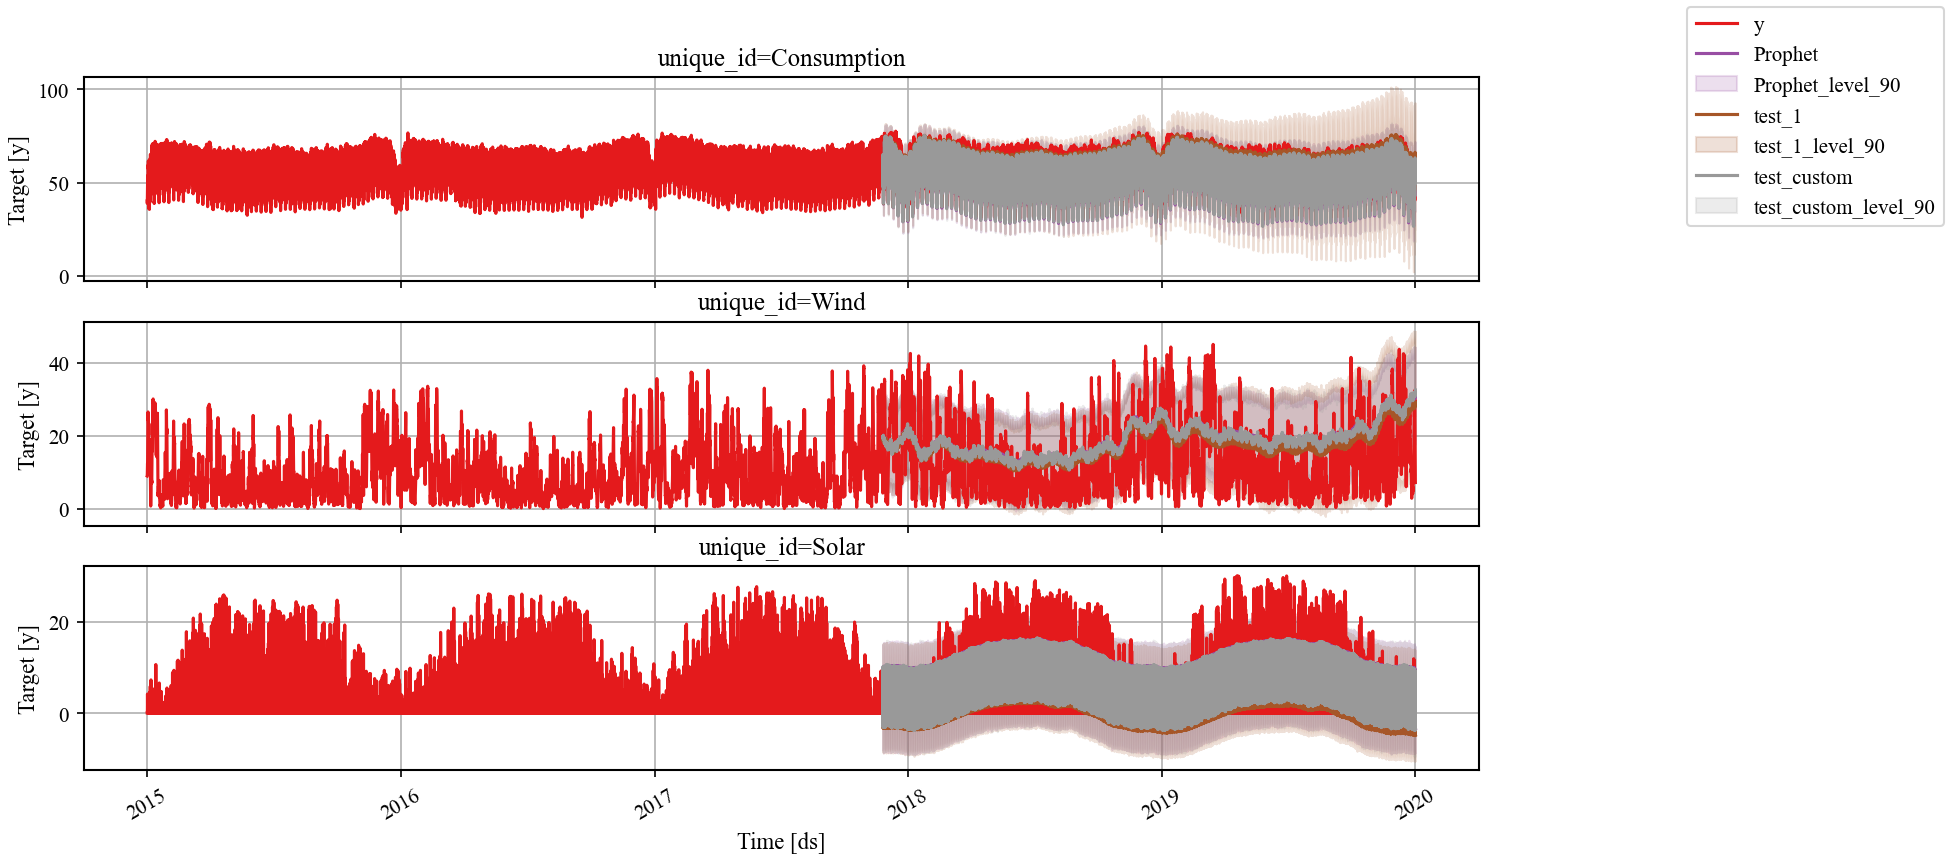

In [75]:

evaluate_and_plot(df_train, df_test, eval_sf, metrics = [mae, rmse, ], levels=LEVELS[1:])

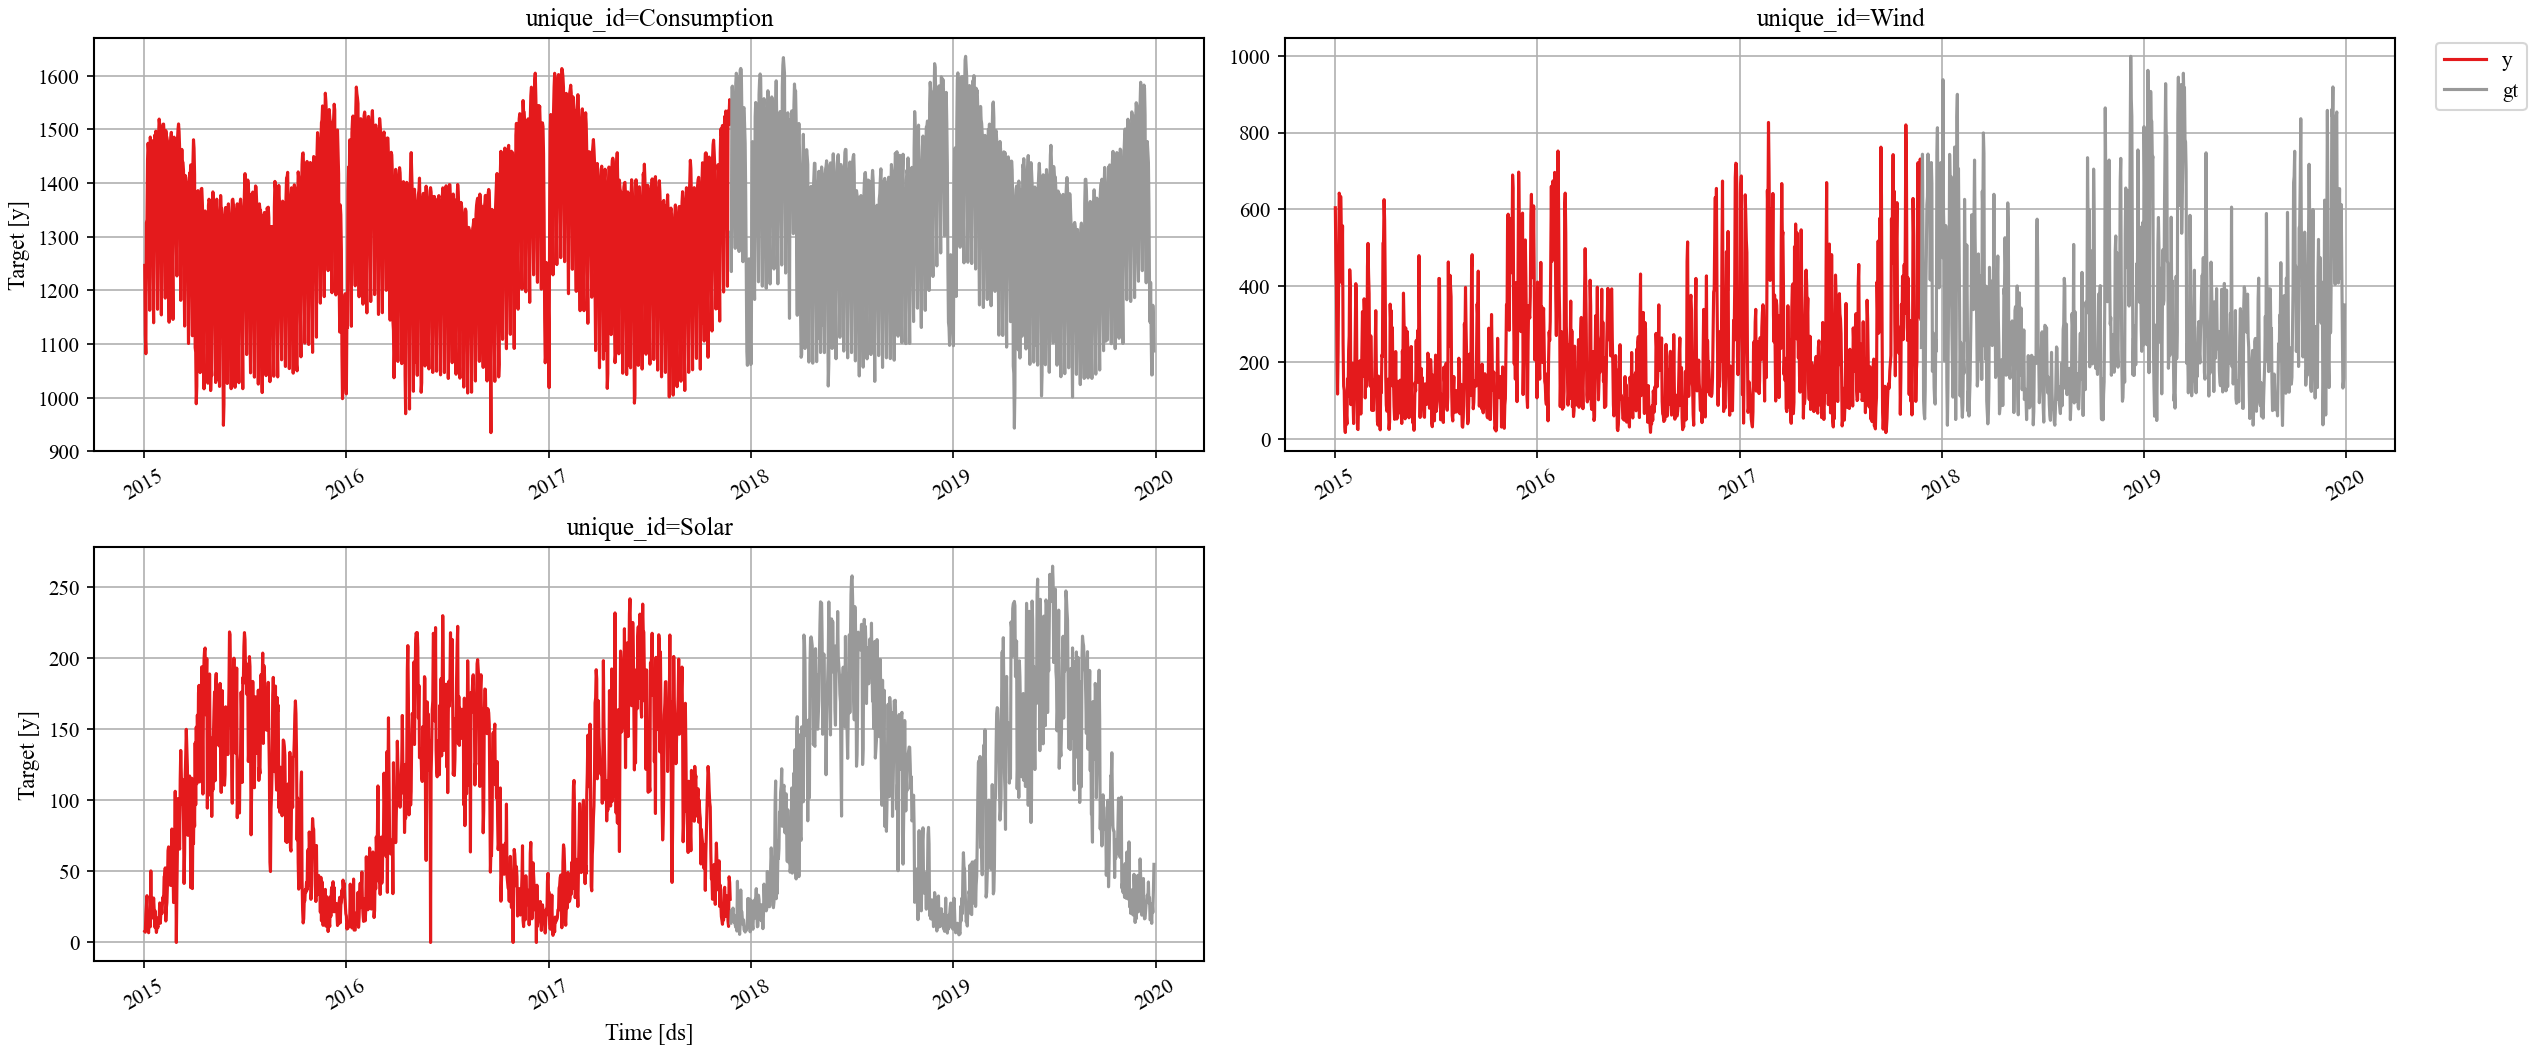

In [63]:
y = df_.resample('D').agg({
    'Consumption': 'sum',
    'Wind': 'sum',
    'Solar': 'sum',
    'temperature': 'mean',
    'radiation_direct_horizontal': 'mean'
}).ffill().bfill() + 1e-8

y = y.iloc[1:-2]



ts = ['Consumption', 'Wind', 'Solar']
base_cols = ['unique_id', 'ds', 'y']

date_index = y.index
panel_list = [pd.DataFrame({'ds':date_index , 'y': y[t].values, 'unique_id': t}) for t in ts]
panel_df = pd.concat(panel_list, ignore_index=True)
panel_df = panel_df[base_cols] #порядок колонок
panel_df.sample(5)

FREQ = y.index.freq

# SEASON = find_season_length(y['Consumption'].values, max_season_length = 55)
SEASON = [7,365] # 53 недели в году

FH = int(0.42 * y.shape[0])

df_test  = panel_df[base_cols].groupby("unique_id").tail(FH)
df_train = panel_df[base_cols].drop(df_test.index).reset_index(drop=True)

plot_series(df_train, df_test.rename(columns={"y": "gt"}),  palette='Set1')

In [64]:
models = [TSProphet(freq=FREQ,     
                    weekly_seasonality=True,
                    yearly_seasonality=True,
                    alias='test_1' ),
          TSProphet(freq=FREQ, 
                       seasonality_mode='additive',
                        seasonality_prior_scale=0.9,  # уменьшили — сезонность будет мягче
                        changepoint_prior_scale=0.01,  # уменьшили — тренд будет мягче
                        add_country_holidays='GE',
                        weekly_seasonality=True,
                        yearly_seasonality=True)]

sf = StatsForecast(models=models, freq=FREQ, n_jobs=1)

fcst_sf = sf.forecast(df=df_train, h=FH, level = LEVELS, fitted=True)

in_sample = sf.forecast_fitted_values()

eval_sf = df_test.merge(fcst_sf, on=['unique_id', 'ds'])

21:12:23 - cmdstanpy - INFO - Chain [1] start processing
21:12:24 - cmdstanpy - INFO - Chain [1] done processing
21:12:24 - cmdstanpy - INFO - Chain [1] start processing
21:12:24 - cmdstanpy - INFO - Chain [1] done processing
21:12:25 - cmdstanpy - INFO - Chain [1] start processing
21:12:25 - cmdstanpy - INFO - Chain [1] done processing
21:12:25 - cmdstanpy - INFO - Chain [1] start processing
21:12:25 - cmdstanpy - INFO - Chain [1] done processing
21:12:26 - cmdstanpy - INFO - Chain [1] start processing
21:12:26 - cmdstanpy - INFO - Chain [1] done processing
21:12:27 - cmdstanpy - INFO - Chain [1] start processing
21:12:27 - cmdstanpy - INFO - Chain [1] done processing


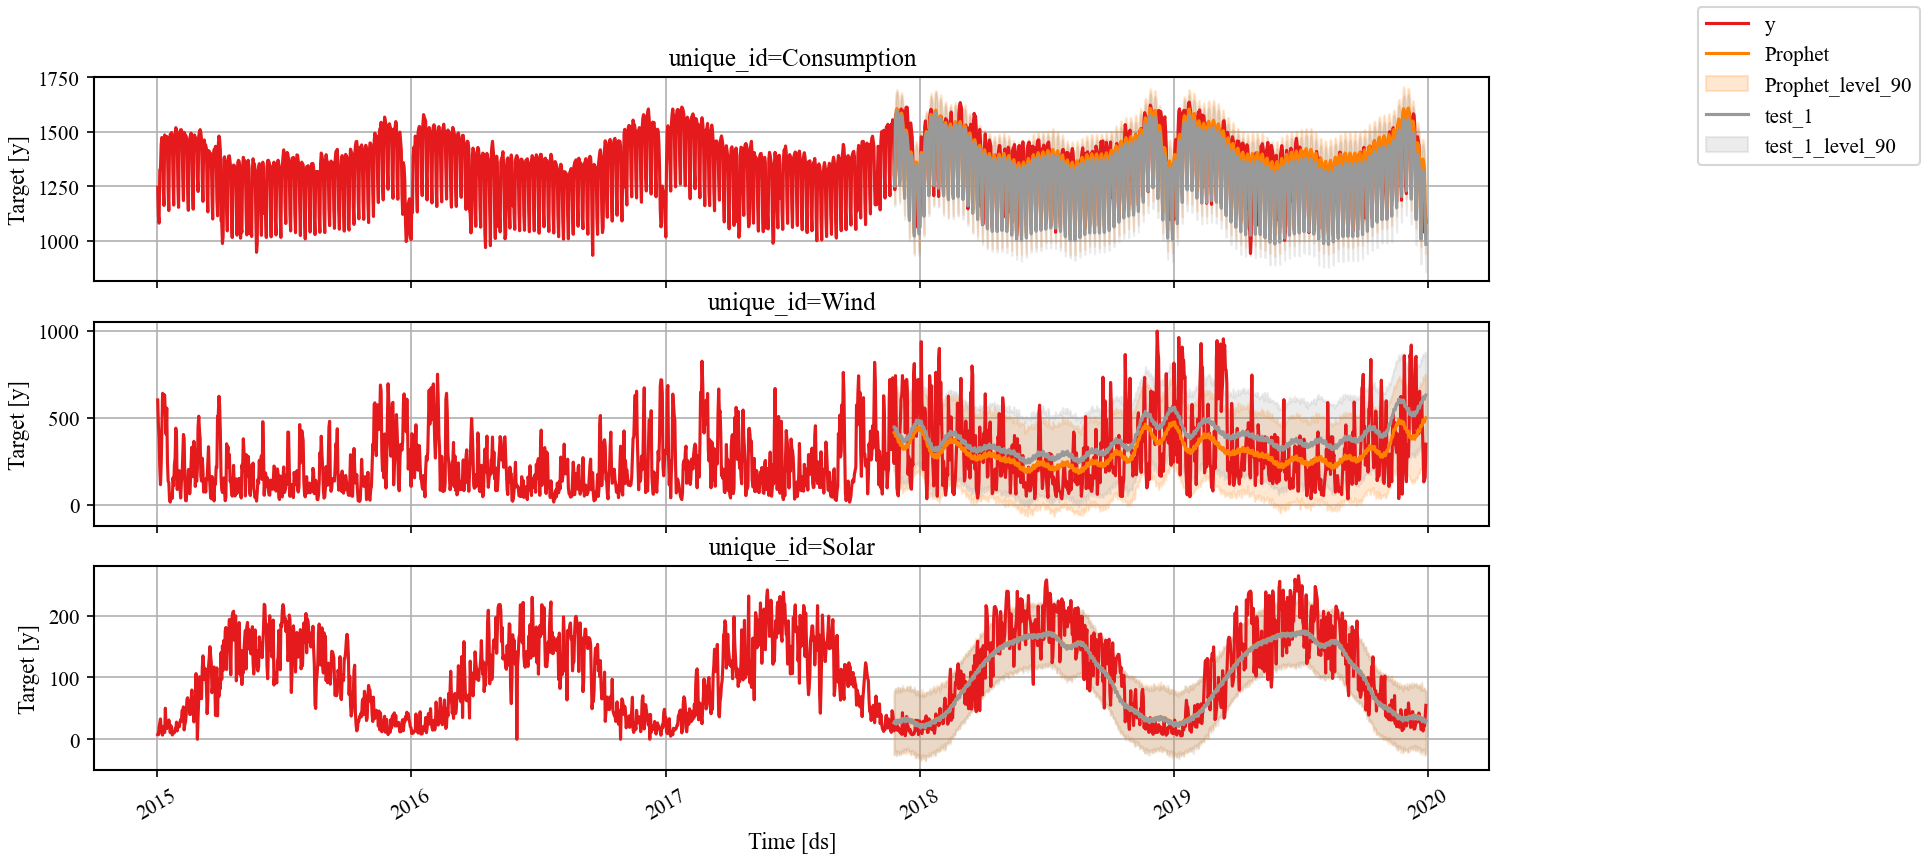

In [65]:

evaluate_and_plot(df_train, df_test, eval_sf, metrics = [mae, rmse, ], levels=LEVELS[1:])